In [10]:
#Function 7
#You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, 
#regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score
#(such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
#Because this is a commonly used model, you might benefit from researching best practices or literature 
#to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# 1. Load 6D spatial coordinate data and output values
inputs6D = np.load('/home/mcevoyj777/_CAPSTONE/FUNC7/initial_inputs.npy')
output6D = np.load('/home/mcevoyj777/_CAPSTONE/FUNC7/initial_outputs.npy')
print(output6D.max())
extra_inputs = [[0.029217, 0.445624, 0.284957, 0.173546, 0.367695, 0.732927],
                [0.104372, 0.225659, 0.433356, 0.136422, 0.338113, 0.943647],
                [0.000000, 0.267792, 0.069571, 0.000000, 0.227411, 0.803541],
                [0.001724, 0.382795, 0.427673, 0.142881, 0.342742, 0.752438],
                [0.000000, 0.453311, 0.438465, 0.069844, 0.341572, 0.763047],
                [0.006345, 0.293373, 0.396797, 0.244223, 0.348086, 0.733486],
                [0.005211, 0.293373, 0.396797, 0.221541, 0.362141, 0.785230],
               [0.000000, 0.203680, 0.650701, 0.281315, 0.329023, 0.683525]]
extra_output = [1.6212926285983933,1.3627627244158926,0.7161023344103655,
                1.8414404584309458,1.3053428311606587,2.4255002691625127,
               2.1460336008706697,2.544740511527827]

inputs6D = np.vstack([inputs6D, extra_inputs])
output6D = np.append(output6D, extra_output)
print(output6D.max())
print(inputs6D)
print(output6D)


# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs6D, columns=['Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'])
df['Output_Target'] = output6D

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships are non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs6D, output6D)

for name, score in zip(['Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")


# Fit a quick non-linear model that checks all 4 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs6D, output6D)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

1.3649683044991994
2.544740511527827
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.7119575

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 30 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs6D, output6D)

def objective_6d(X):
    """
    Surrogate function for 6D optimization.
    X: A 2D numpy array of shape (n_samples, 6) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [4]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=1, 
                            n_initial=5, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs6D
    y_samples = output6D

    initial_length_scales = np.array([
        0.10,  # Input_U: Hyper-critical foundation, requires micro-adjustments
        1.00,  # Input_V: Passive parameter, smooth it out completely
        1.00,  # Input_W: Passive parameter, smooth it out completely
        0.30,  # Input_X: Moderate importance
        0.30,  # Input_Y: High non-linear importance, requires precise sweet-spotting
        0.15   # Input_Z: Strong positive accelerator, push boundaries carefully
    ])
    length_scale_bounds = [(1e-2, 1e2) for _ in range(n_dims)]
    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")
      
    
    for iteration in range(n_iterations):
        # Fit GP
        ard_kernel = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=initial_length_scales, 
            length_scale_bounds=length_scale_bounds, 
            nu=2.5  # nu=2.5 enforces Matérn 5/2 behavior
            )
        gp = GaussianProcessRegressor(kernel=ard_kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=10)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max())
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=0.5)
           
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None
        
        for _ in range(50):  # More starts for higher dimensions
            x0 = np.random.uniform(0, 1, n_dims)
            result = minimize(acq_objective, x0, bounds=bounds, method='L-BFGS-B')
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")

       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
    return X_samples, y_samples, best_values



# Run 6D optimization
X_samples_6d, y_samples_6d, best_values_6d = bayesian_optimization_nd(
    objective_6d, 
    n_dims=6,
    n_iterations=3,
    acquisition=''
)


Starting 6D optimization with 5 initial samples...
Initial best: 2.5447

Optimized Next Point Found! Predicted Acquisition Score: 2.571674
Coordinates to test next: [0.         0.69912571 0.82218291 0.2576443  0.32613524 0.25637084]
Optimized Next Point Found! Predicted Acquisition Score: 2.571682
Coordinates to test next: [0.         0.30736969 0.31813168 0.25761442 0.32611169 0.49302813]
Optimized Next Point Found! Predicted Acquisition Score: 2.571710
Coordinates to test next: [0.         0.78035458 0.24942792 0.25765636 0.32612839 0.91668353]
Optimized Next Point Found! Predicted Acquisition Score: 2.571711
Coordinates to test next: [0.         0.23335555 0.05351456 0.25764706 0.32612502 0.36469066]
Optimized Next Point Found! Predicted Acquisition Score: 2.622534
Coordinates to test next: [0.         0.65327973 0.83066094 0.28154778 0.33165494 0.84816125]
Optimized Next Point Found! Predicted Acquisition Score: 2.622552
Coordinates to test next: [0.         0.61233325 0.29349081 0

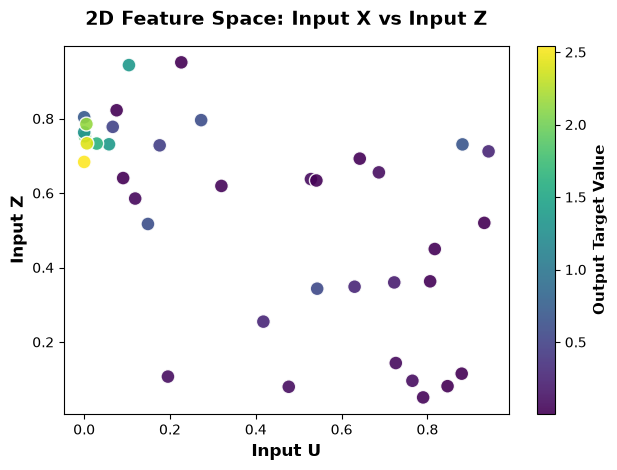

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_U', 
    y='Input_Z', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input U', fontsize=12, fontweight='bold')
plt.ylabel('Input Z', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input X vs Input Z', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load the 6D dataset (Features: U, V, W, X, Y, Z)
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.9246939 , 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.6402654 ],
    [0.11886697, 0.61505494, 0.90581639, 0.8553003 , 0.41363143, 0.58523563],
    [0.63021764, 0.8380969 , 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.6924164 ],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.5590408 , 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.8072454 , 0.6354384 , 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.6190825 ],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.285009   , 0.69156848, 0.6555429 ],
    [0.17597754, 0.6244165  , 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.8160952  , 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.5523983  , 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.7193764  , 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.9986547  , 0.07966402],
    [0.029217  , 0.445624  , 0.284957  , 0.173546  , 0.367695  , 0.732927  ],
    [0.104372  , 0.225659  , 0.433356  , 0.136422  , 0.338113  , 0.943647  ],
    [0.        , 0.267792  , 0.069571  , 0.        , 0.227411  , 0.803541  ],
    [0.001724  , 0.382795  , 0.427673  , 0.142881  , 0.342742  , 0.752438  ],
    [0.        , 0.453311  , 0.438465  , 0.069844  , 0.341572  , 0.763047  ],
    [0.        , 0.293373  , 0.396797  , 0.244223  , 0.348086  , 0.733486  ],
    [0.005211  , 0.293373  , 0.396797  , 0.221541  , 0.362141  , 0.78523   ],
    [0.        , 0.20368   , 0.650701  , 0.281315  , 0.329023  , 0.683525  ]
])

y_train = np.array([
    0.6044327, 0.56275307, 0.00750324, 0.0614243, 0.2730468, 0.08374657,
    1.3649683, 0.09264495, 0.0178696, 0.03356494, 0.0735163, 0.2063097,
    0.00882563, 0.26840032, 0.61152553, 0.01479818, 0.27489251, 0.06676325,
    0.04211835, 0.00270147, 0.01820907, 0.00701603, 0.10050661, 0.47539552,
    0.67514163, 0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.62129263, 1.36276272, 0.71610233, 1.84144046, 1.30534283, 2.42550027,
    2.1460336, 2.54474051
])

# 2. Configure a Matern GP Surrogate Model
# Matern nu=1.5 allows for the distinct "cliffs" visible when U shifts off 0.0.
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(6), length_scale_bounds=(1e-2, 10.0), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6, random_state=42)

# Fit model to historical space
gp.fit(X_train, y_train)

# 3. Formulate Optimization Target (Negative prediction for minimization algorithm)
def objective(x):
    # Predict returns shape (1, 6), flatten to extract scalar
    return -float(gp.predict(x.reshape(1, -1))[0])

# 4. Enforce Bounding Box System limits [0.0, 1.0]
bounds = [
    (0.0, 0.05),   # U: Aggressively bounded close to its zero cliff
    (0.15, 0.35),  # V
    (0.45, 0.80),  # W
    (0.15, 0.35),  # X
    (0.25, 0.45),  # Y
    (0.60, 0.85)   # Z
]

# Use your historical peak coordinate as the optimization warm-start point
x_start = np.array([0.0, 0.20368, 0.650701, 0.281315, 0.329023, 0.683525])

# 5. Execute L-BFGS-B Optimization Local Search
result = minimize(objective, x_start, method='L-BFGS-B', bounds=bounds)

# 6. Display Predicted Coordinates
print("--- GAUSSIAN PROCESS TARGET PREDICTION ---")
print(f"Predicted Max Output: {abs(result.fun):.4f}")
print("Optimal Coordinates:")
for name, val in zip(['U', 'V', 'W', 'X', 'Y', 'Z'], result.x):
    print(f"  Input_{name}: {val:.6f}")

--- GAUSSIAN PROCESS TARGET PREDICTION ---
Predicted Max Output: 2.5611
Optimal Coordinates:
  Input_U: 0.000000
  Input_V: 0.232237
  Input_W: 0.595069
  Input_X: 0.273864
  Input_Y: 0.333299
  Input_Z: 0.695738
